# 13 — A1 `hsmm_tstudent`: HSMM t-Student con duraciones explícitas · extensión F3

**Familia F3 (HMM semi-Markov).** Un *Hidden Semi-Markov Model* (HSMM) extiende el HMM t-Student de D8 relajando su supuesto temporal más restrictivo: en un HMM la duración de cada régimen es **geométrica y sin memoria**. D13 modela explícitamente cuánto dura cada estado; la probabilidad de salir depende de la **edad del episodio**, no solo del estado actual.

El experimento es controlado: conserva las **mismas 7 features puente**, la misma ventana, el mismo número de estados seleccionado entre `{3, 4}`, las mismas emisiones t-Student multivariantes y la misma evaluación walk-forward. Solo cambia la dinámica temporal:

- **D8 — t-HMM:** permanencia geométrica inducida por la diagonal de la matriz de transición.
- **D13 — t-HSMM:** duración Gamma desplazada por estado, truncada en `D_MAX=126` días y regularizada hacia la geometría de D8.

> **Alcance de la estimación.** D13 usa una estimación transparente en dos etapas: primero ajusta las emisiones t y la dinámica HMM de D8; después estima las duraciones explícitas y la cadena de saltos a partir de los episodios del train. No es un EM conjunto HSMM. Por tanto, el BIC que se muestra es una aproximación útil para selección interna y no debe interpretarse como evidencia definitiva frente a D8.

**Causalidad.** En walk-forward se filtra el estado ampliado `P(S_t, edad_t | observaciones ≤ t)` con parámetros ajustados solo en el pasado. La ruta segmental completa se utiliza exclusivamente como diagnóstico **in-sample (NO causal)**.

**Hipótesis previa:** frente a D8, el HSMM debería reducir el *switching* espurio y aumentar la coherencia de 2008, 2020 y 2022 sin perder demasiada sensibilidad. Puede reaccionar peor a shocks breves si la regularización de duración es excesiva.


## Índice navegable

| # | Sección | Figura |
|---:|---|---|
| 1 | [Selección de K por BIC aproximado sobre {3, 4}](#s1) | — |
| 2 | [Detector desplegado: parámetros y monotonía in-sample](#s2) | — |
| 3 | [Espacio de las 7 features puente (PCA 2D)](#s3) | `d13_feature_scatter.png` |
| 4 | [Duraciones explícitas vs geométricas: PMF y hazard](#s4) | `d13_explicit_durations.png` |
| 5 | [Walk-forward causal semi-Markov](#s5) | — |
| 6 | [Evaluación estandarizada y fila de métricas](#s6) | CSV |
| 7 | [Monotonía económica en walk-forward](#s7) | — |
| 8 | [Severidad por estado en walk-forward](#s8) | `d13_state_severity.png` |
| 9 | [S&P 500 coloreado por los K estados](#s9) | `d13_hsmm_sp500_regimes.png` |
| 10 | [Probabilidad filtrada de crisis](#s10) | `d13_hsmm_crisis_proba.png` |
| 11 | [Cadena embebida y duración esperada](#s11) | `d13_transition_duration.png` |
| 12 | [Crisis, trampas y fragmentación](#s12) | — |
| 13 | [Comparación controlada D13 vs D8](#s13) | `d13_vs_d8.png` |
| 14 | [Conclusión y contraste de la hipótesis](#s14) | — |


In [1]:
%matplotlib inline
import sys, warnings, logging
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
warnings.filterwarnings('ignore')
logging.getLogger('hmmlearn').setLevel(logging.CRITICAL)

ROOT = Path.cwd()
while not (ROOT / 'src').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
RESULTS = ROOT / 'results'; RESULTS.mkdir(exist_ok=True)

from src import evaluation as ev
from src import viz
from detectors.hsmm_tstudent import HSMMTStudent
from detectors.hmm_gaussian_2s import BRIDGE_FEATURES
viz.use_house_style()

feats = pd.read_parquet(ROOT / 'data' / 'processed' / 'features.parquet')
raw   = pd.read_parquet(ROOT / 'data' / 'raw' / 'raw_panel.parquet')
X = feats[BRIDGE_FEATURES].copy()
mkt = np.log(raw['SP500'] / raw['SP500'].shift(1)).reindex(X.index)
spx = raw['SP500'].reindex(X.index)

D_MAX = 126                 # ~6 meses; la última celda acumula toda la cola
DURATION_PRIOR = 12.0       # episodios equivalentes del prior geométrico
TRANSITION_PRIOR = 2.0
print('Features puente (7):', BRIDGE_FEATURES)
print('Ventana:', X.index.min().date(), '->', X.index.max().date(), '| n =', len(X))
print(f'HSMM: D_MAX={D_MAX} | prior duración={DURATION_PRIOR:g} | prior saltos={TRANSITION_PRIOR:g}')


Features puente (7): ['SP500_ret_z', 'TLT_ret_z', 'IEF_ret_z', 'HYG_ret_z', 'SP500_vol_z', 'credit_spread_z', 'VIX_level_z']
Ventana: 2007-07-06 -> 2026-08-26 | n = 4692
HSMM: D_MAX=126 | prior duración=12 | prior saltos=2


## <a id="s1"></a>1. Selección de K por BIC aproximado sobre {3, 4} (comparable con D8)

Ajustamos `K=3` y `K=4` sobre toda la ventana. Las emisiones t son las de D8; D13 añade una Gamma desplazada de dos parámetros por estado y elimina las auto-transiciones de la cadena embebida. El recuento dinámico tiene **K parámetros netos más que D8**.

El BIC sirve aquí para seleccionar la complejidad **dentro de D13**. Al tratarse de una estimación en dos etapas, la comparación BIC con D8 se presenta después como diagnóstico, no como test concluyente.


In [2]:
rows, fits = [], {}
for k in (3, 4):
    d = HSMMTStudent(
        n_states=k, n_init=4, t_n_iter=30,
        max_duration=D_MAX,
        duration_prior_strength=DURATION_PRIOR,
        transition_prior_strength=TRANSITION_PRIOR,
    ).fit(X)
    d.label_states_economically(X, market_returns=mkt)
    fits[k] = d
    dur = d.duration_parameters_canonical()['mean_days']
    rows.append({
        'k': k, 'logL_HSMM': d.score(X), 'n_params': d.n_parameters(),
        'AIC_aprox': d.aic(X), 'BIC_aprox': d.bic(X),
        'dur_min': dur.min(), 'dur_max': dur.max(),
    })
sel = pd.DataFrame(rows).set_index('k')
display(sel.round(1))
K = int(sel['BIC_aprox'].idxmin())
print(f'K* por BIC aproximado = {K} | BIC={sel.loc[K, "BIC_aprox"]:.1f}')
print('El criterio se usa para seleccionar K dentro de D13; ver cautela metodológica de la introducción.')


,logL_HSMM,n_params,AIC_aprox,BIC_aprox,dur_min,dur_max
k,,,,,,
3,-13599.3,119,27436.7,28204.7,31.0,62.0
4,-11458.9,163,23243.7,24295.7,21.1,71.5


K* por BIC aproximado = 4 | BIC=24295.7
El criterio se usa para seleccionar K dentro de D13; ver cautela metodológica de la introducción.


## <a id="s2"></a>2. Detector desplegado (K*): parámetros por estado y monotonía IN-SAMPLE

La ruta HSMM segmental usa toda la muestra y por tanto es **NO causal**; aquí solo diagnostica el ajuste. Los estados se ordenan canónicamente de calma a crisis usando volatilidad y retorno del S&P 500.


In [3]:
det = fits[K]
st_is = pd.Series(det.predict(X), index=X.index, name='state')  # Viterbi HSMM, NO causal
ST_LABELS = (['calma', 'corrección', 'crisis'] if K == 3
             else ['calma', 'leve', 'corrección', 'crisis'])
dur_par = det.duration_parameters_canonical()
nu_c = det.dofs_canonical()

print('Detector:', det.name, '| crisis_state canónico =', det.crisis_state, '| K =', K)
print('Bibliografía:', det.bibliography)
print('\n--- Parámetros por estado canónico (diagnóstico in-sample) ---')
rmean, rvol = [], []
for s in range(K):
    r = mkt[st_is == s]
    rmean.append(float(r.mean()*252)); rvol.append(float(r.std()*np.sqrt(252)))
    print(f'  {s} [{ST_LABELS[s]:10s}] ret_ann={rmean[-1]:+7.2%} | vol_ann={rvol[-1]:6.2%} '
          f'| ν={nu_c[s]:5.2f} | E[D]={dur_par.loc[s, "mean_days"]:5.1f} d | n={len(r)}')
mono_vol_is = all(rvol[i] < rvol[i+1] for i in range(K-1))
print('\nMonotonía de VOL in-sample:', mono_vol_is)
if not mono_vol_is:
    print('ATENCIÓN: revisar el orden económico; no se fuerza una conclusión mediante assert.')
display(dur_par.round(2))


Detector: hsmm_tstudent_4s | crisis_state canónico = 3 | K = 4
Bibliografía: ['hmm_bullabulla2006', 'hmm_bulla2011', 'hmm_rabiner1989', 'guidolintimmermann2007']

--- Parámetros por estado canónico (diagnóstico in-sample) ---
  0 [calma     ] ret_ann=+21.59% | vol_ann= 8.10% | ν=10.55 | E[D]= 33.0 d | n=1307
  1 [leve      ] ret_ann=+13.36% | vol_ann=12.55% | ν= 8.06 | E[D]= 21.1 d | n=1299
  2 [corrección] ret_ann= -9.01% | vol_ann=23.15% | ν= 3.94 | E[D]= 43.7 d | n=1226
  3 [crisis    ] ret_ann= +0.53% | vol_ann=32.37% | ν= 2.42 | E[D]= 71.5 d | n=860

Monotonía de VOL in-sample: True


,shape_gamma,scale_gamma,mean_days,median_days,mode_days
state,,,,,
0,0.60,58.33,32.97,19.0,1.0
1,0.98,20.99,21.12,15.0,1.0
2,0.66,77.10,43.75,29.0,126.0
3,0.64,202.95,71.51,72.0,126.0


## <a id="s3"></a>3. Espacio de las 7 features puente (PCA 2D) por estado

La figura reproduce el diagnóstico espacial de D8. Si la partición cambia mucho pese a mantener las emisiones, la ley de duración está reasignando observaciones fronterizas y no solo suavizando episodios.


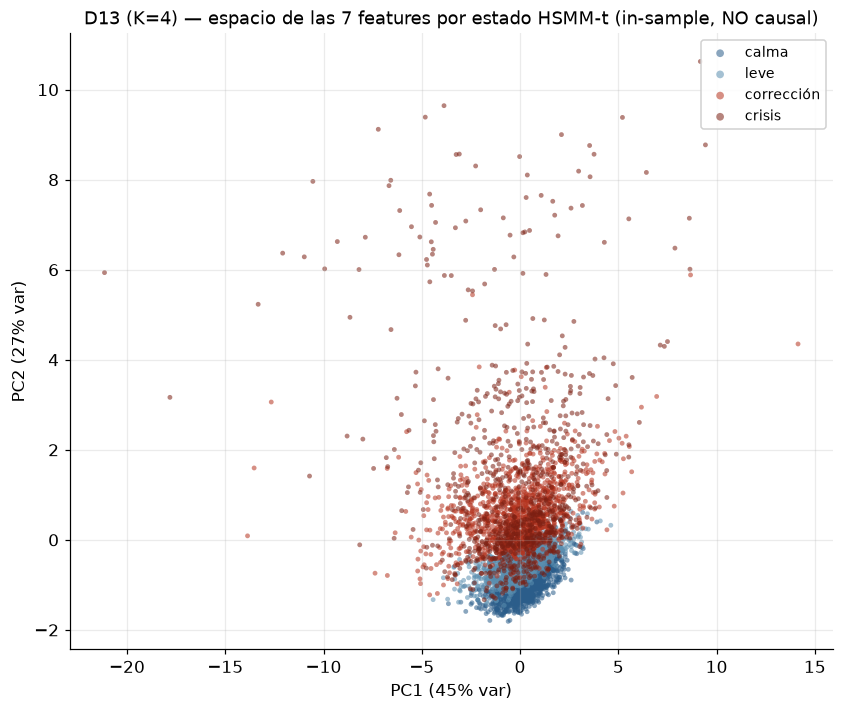

In [4]:
fig, ax = plt.subplots(figsize=(7.8, 6.6))
viz.plot_feature_space_scatter(
    X, st_is, use_pca=True, crisis_state=det.crisis_state, labels=ST_LABELS, ax=ax,
    title=f'D13 (K={K}) — espacio de las 7 features por estado HSMM-t (in-sample, NO causal)')
fig.tight_layout()
fig.savefig(RESULTS / 'd13_feature_scatter.png', dpi=110, bbox_inches='tight'); plt.show()


## <a id="s4"></a>4. Duraciones explícitas vs geométricas — PMF y hazard · figura central

Esta es la diferencia mecánica entre D13 y D8:

- En D8 el *hazard* de salida es constante: `h(d)=1-A_ss` para cualquier edad `d`.
- En D13 cada estado tiene una PMF de duración y un *hazard* dependiente de la edad: `h_s(d)=P(D=d | D≥d)`.

La línea continua muestra D13 y la discontinua la geometría implícita del HMM-t de arranque. El último bin (`D_MAX`) acumula la cola y no debe interpretarse como un pico literal.


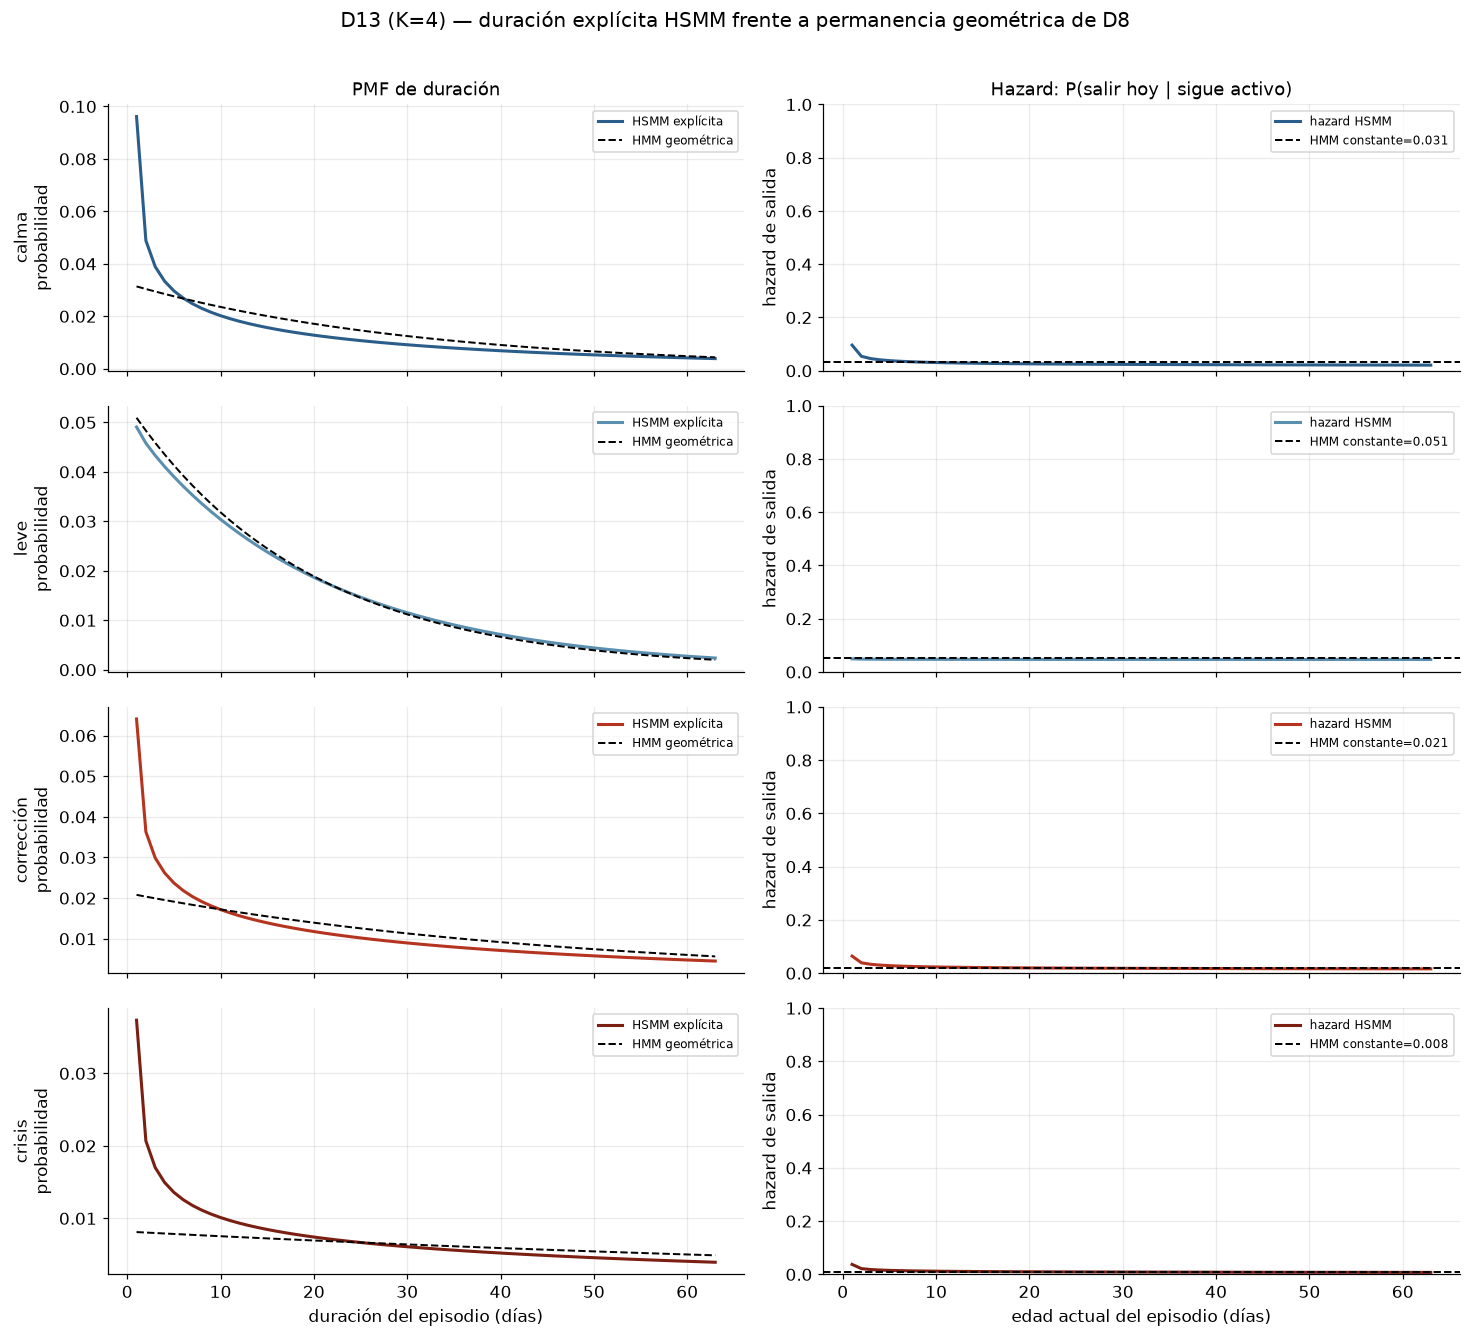

,mean_days,median_days,mode_days,hmm_geometric_mean
state,,,,
0,32.97,19.0,1.0,31.88
1,21.12,15.0,1.0,19.63
2,43.75,29.0,126.0,48.09
3,71.51,72.0,126.0,123.42


In [5]:
days = np.arange(1, D_MAX + 1)
q = det.duration_pmf_canonical()
h = det.duration_hazard_canonical()
A_hmm = det.hmm_transition_canonical()
SHOW_D = min(63, D_MAX)  # primer trimestre bursátil para que la forma sea visible

fig, axes = plt.subplots(K, 2, figsize=(13.5, 3.0*K), sharex='col')
if K == 1:
    axes = axes[None, :]
for s in range(K):
    color = viz.regime_color(s, K)
    p_exit = float(np.clip(1 - A_hmm[s, s], 1/D_MAX, 0.999))
    geom = p_exit * (1-p_exit)**(days-1)
    geom[-1] += max(0.0, 1.0 - geom.sum())
    axes[s, 0].plot(days[:SHOW_D], q[s, :SHOW_D], color=color, lw=2.0, label='HSMM explícita')
    axes[s, 0].plot(days[:SHOW_D], geom[:SHOW_D], color='black', ls='--', lw=1.3, label='HMM geométrica')
    axes[s, 0].set_ylabel(f'{ST_LABELS[s]}\nprobabilidad')
    axes[s, 0].legend(fontsize=8)
    axes[s, 1].plot(days[:SHOW_D], h[s, :SHOW_D], color=color, lw=2.0, label='hazard HSMM')
    axes[s, 1].axhline(p_exit, color='black', ls='--', lw=1.3, label=f'HMM constante={p_exit:.3f}')
    axes[s, 1].set_ylabel('hazard de salida'); axes[s, 1].set_ylim(0, 1)
    axes[s, 1].legend(fontsize=8)
axes[-1, 0].set_xlabel('duración del episodio (días)')
axes[-1, 1].set_xlabel('edad actual del episodio (días)')
axes[0, 0].set_title('PMF de duración')
axes[0, 1].set_title('Hazard: P(salir hoy | sigue activo)')
fig.suptitle(f'D13 (K={K}) — duración explícita HSMM frente a permanencia geométrica de D8', y=1.01)
fig.tight_layout()
fig.savefig(RESULTS / 'd13_explicit_durations.png', dpi=110, bbox_inches='tight'); plt.show()

compare_dur = dur_par[['mean_days', 'median_days', 'mode_days']].copy()
compare_dur['hmm_geometric_mean'] = [1/max(1-A_hmm[s, s], 1/D_MAX) for s in range(K)]
display(compare_dur.round(2))


## <a id="s5"></a>5. Walk-forward CAUSAL: filtrado forward semi-Markov

Cada fold se ajusta solo con observaciones anteriores al bloque OOS. El filtro propaga la distribución conjunta `(estado, edad)` y usa como *burn-in* únicamente el train pasado. `STEP=126` mantiene la misma frecuencia semestral de D8.


In [6]:
TRAIN_SIZE = 252 * 5
STEP = 126
factory = lambda: HSMMTStudent(
    n_states=K, n_init=3, t_n_iter=25,
    max_duration=D_MAX,
    duration_prior_strength=DURATION_PRIOR,
    transition_prior_strength=TRANSITION_PRIOR,
)
panel = ev.walk_forward(
    factory, X, market_returns=mkt,
    train_size=TRAIN_SIZE, step=STEP, expanding=True,
)
print('Panel OOS:', panel.shape, '|', panel.index.min().date(), '->', panel.index.max().date())
print('Folds:', panel['fold'].nunique(), '| probabilidades válidas:', panel['p_crisis'].between(0, 1).all())
panel.head(3)


Panel OOS: (3432, 3) | 2012-07-31 -> 2026-08-26
Folds: 28 | probabilidades válidas: True


,state,p_crisis,fold
date,,,
2012-07-31,0,1.612534e-11,0
2012-08-01,0,1.851010e-09,0
2012-08-02,0,2.150061e-10,0


## <a id="s6"></a>6. Evaluación estandarizada y fila de métricas

Se usa exactamente el evaluador común: cobertura, falsas alarmas, *lead/lag*, *switching*, duración media, estabilidad de etiqueta, silueta y bondad de ajuste. La fila se guarda con el mismo esquema que D8.


In [7]:
res = ev.evaluate(det, panel, market_returns=mkt.reindex(panel.index), X_full=X)
row = ev.results_table([res])
out_csv = RESULTS / 'metrics_13_hsmm.csv'
row.to_csv(out_csv, index=False)
print('ventana_eval:', res.extra['ventana_eval'])
print('retorno medio por estado canónico (OOS):',
      {k_: round(v, 5) for k_, v in res.extra['mean_return_by_state'].items()})
print('Guardado:', out_csv.name, '| columnas =', row.shape[1])
display(row.T)


ventana_eval: 2012-07-31→2026-08-26 (n=3432)
retorno medio por estado canónico (OOS): {0: 0.00048, 1: 0.00039, 2: 0.00029, 3: 0.00097}
Guardado: metrics_13_hsmm.csv | columnas = 32


,0
detector,hsmm_tstudent_4s
n_states,4
ventana_eval,2012-07-31→2026-08-26 (n=3432)
oos_start,2012-07-31
oos_end,2026-08-26
n_oos,3432
false_alarm_rate,0.413669
switching_rate,0.049534
mean_regime_duration,20.070175
label_stability,0.89756


## <a id="s7"></a>7. Verificación de monotonía EN WALK-FORWARD

El orden económico se vuelve a fijar en cada fold usando solo los retornos del train. Comprobamos fuera de muestra que la volatilidad aumenta de calma a crisis. Se informa cualquier fallo sin ocultarlo ni detener el resto del análisis.


In [8]:
states_oos = panel['state'].astype(int)
mr_oos = mkt.reindex(panel.index)
vols = []
print('--- Retorno por estado canónico (OOS causal) ---')
for s in range(K):
    r = mr_oos[states_oos == s]
    v = float(r.std()*np.sqrt(252)); vols.append(v)
    print(f'  {s} [{ST_LABELS[s]:10s}] ret_ann={r.mean()*252:+7.2%} | vol_ann={v:6.2%} | n={len(r)}')
mono_vol_wf = all(vols[i] < vols[i+1] for i in range(K-1))
print('\nMonotonía de VOL en walk-forward:', mono_vol_wf)
print('Crisis coincide con la mayor vol:', np.isclose(vols[det.crisis_state], max(vols)))


--- Retorno por estado canónico (OOS causal) ---
  0 [calma     ] ret_ann=+12.00% | vol_ann=10.42% | n=1993
  1 [leve      ] ret_ann= +9.88% | vol_ann=13.71% | n=478
  2 [corrección] ret_ann= +7.25% | vol_ann=21.55% | n=683
  3 [crisis    ] ret_ann=+24.53% | vol_ann=35.87% | n=278

Monotonía de VOL en walk-forward: True
Crisis coincide con la mayor vol: True


## <a id="s8"></a>8. Severidad por estado en walk-forward

La figura replica D8 para que la comparación visual sea directa. La duración explícita actúa sobre la dinámica; no debe destruir la interpretación económica de los estados.


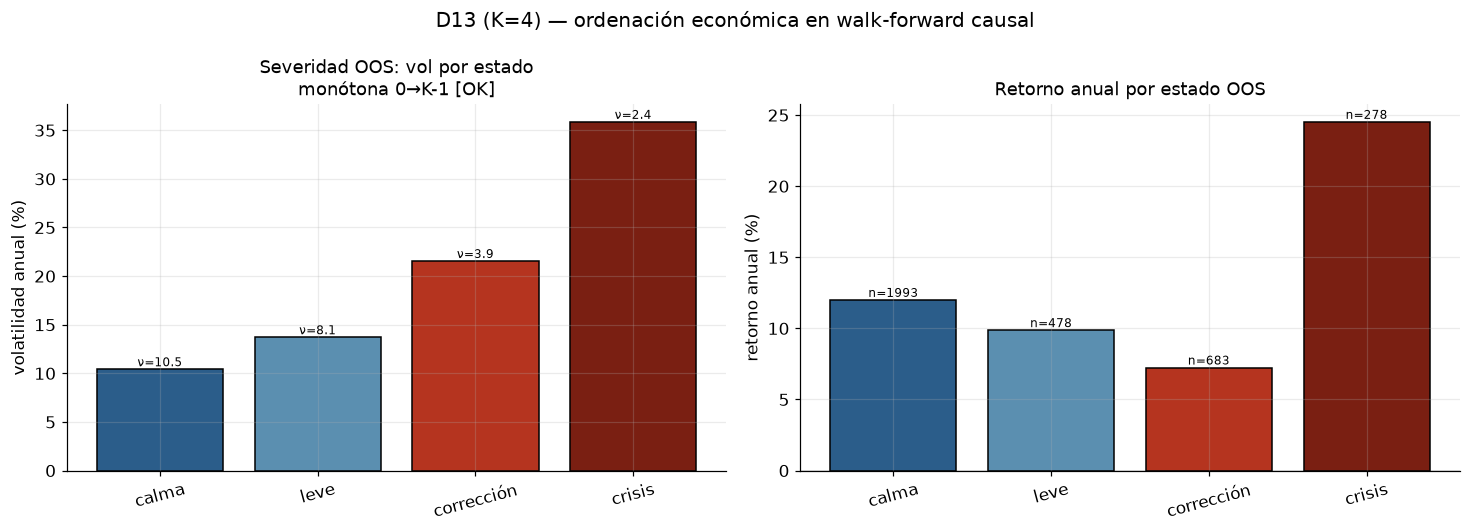

In [9]:
ret_ann_wf, vol_ann_wf, n_wf = [], [], []
for s in range(K):
    r = mr_oos[states_oos == s]
    ret_ann_wf.append(float(r.mean()*252)); vol_ann_wf.append(float(r.std()*np.sqrt(252))); n_wf.append(int(len(r)))
xs_ = np.arange(K)
cols_st = [viz.regime_color(s, K) for s in range(K)]
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13.5, 4.9))
bA = axA.bar(xs_, np.array(vol_ann_wf)*100, color=cols_st, edgecolor='black')
for b, nu in zip(bA, det.dofs_canonical()):
    axA.text(b.get_x()+b.get_width()/2, b.get_height(), f'ν={nu:.1f}', ha='center', va='bottom', fontsize=8)
axA.set_xticks(xs_, ST_LABELS, rotation=15); axA.set_ylabel('volatilidad anual (%)')
axA.set_title(f'Severidad OOS: vol por estado\nmonótona 0→K-1 [{"OK" if mono_vol_wf else "FALLA"}]')
bB = axB.bar(xs_, np.array(ret_ann_wf)*100, color=cols_st, edgecolor='black')
axB.axhline(0, color='black', lw=0.8)
for b, nn in zip(bB, n_wf):
    axB.text(b.get_x()+b.get_width()/2, b.get_height(), f'n={nn}', ha='center',
             va='bottom' if b.get_height() >= 0 else 'top', fontsize=8)
axB.set_xticks(xs_, ST_LABELS, rotation=15); axB.set_ylabel('retorno anual (%)')
axB.set_title('Retorno anual por estado OOS')
fig.suptitle(f'D13 (K={K}) — ordenación económica en walk-forward causal')
fig.tight_layout(); fig.savefig(RESULTS / 'd13_state_severity.png', dpi=110, bbox_inches='tight'); plt.show()


## <a id="s9"></a>9. S&P 500 coloreado por los K estados (out-of-sample)

Cada día se colorea con la etiqueta del filtro semi-Markov causal. Las franjas rojas suaves son crisis conocidas y las naranjas son ventanas trampa.


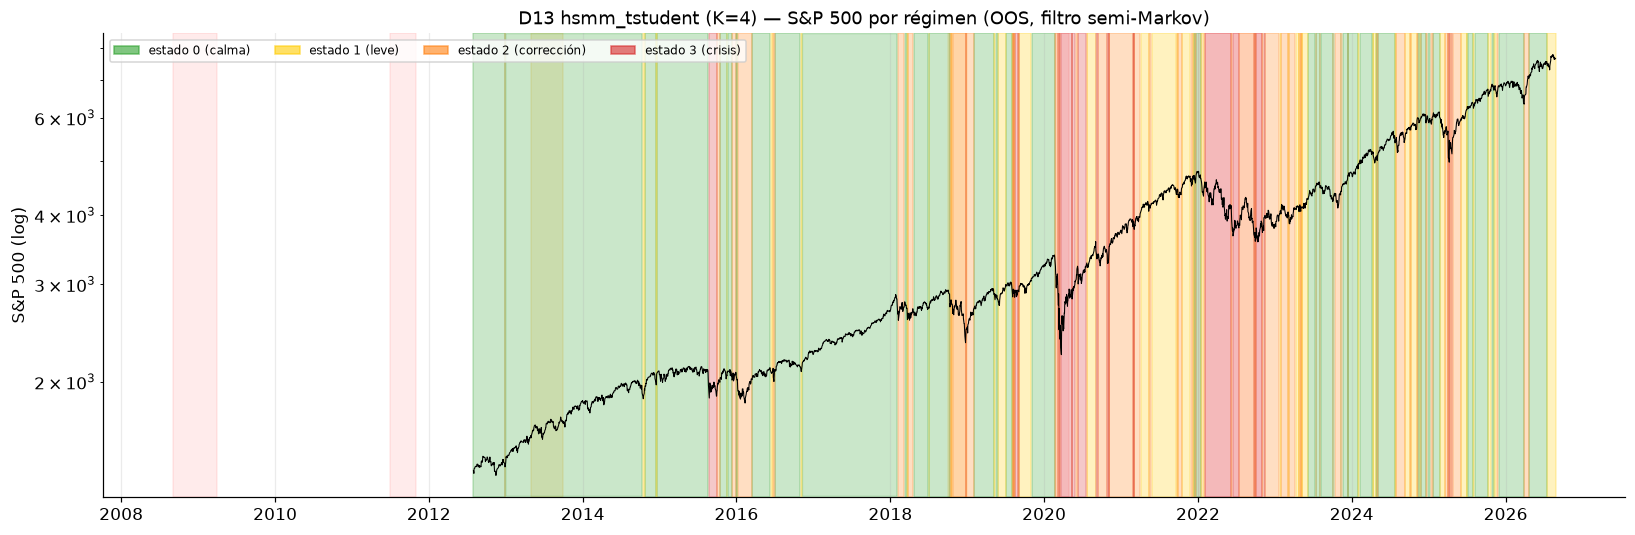

In [10]:
cmap_states = ['#2ca02c', '#ffcc00', '#ff7f0e', '#d62728'][:K]
spx_oos = spx.reindex(panel.index)
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(spx_oos.index, spx_oos, color='black', lw=0.7, zorder=3)
ax.set_yscale('log'); ax.set_ylabel('S&P 500 (log)')
ymin, ymax = ax.get_ylim()
for s in range(K):
    ax.fill_between(panel.index, ymin, ymax, where=(states_oos == s).values,
                    color=cmap_states[s], alpha=0.25, step='mid', zorder=1)
for a, b in ev.CRISIS_WINDOWS.values():
    ax.axvspan(pd.Timestamp(a), pd.Timestamp(b), color='red', alpha=0.08, zorder=0)
for a, b in ev.FALSE_POSITIVE_WINDOWS.values():
    ax.axvspan(pd.Timestamp(a), pd.Timestamp(b), color='orange', alpha=0.15, zorder=0)
ax.set_ylim(ymin, ymax)
handles = [Patch(color=cmap_states[s], alpha=0.6, label=f'estado {s} ({ST_LABELS[s]})') for s in range(K)]
ax.legend(handles=handles, loc='upper left', fontsize=8, ncol=K)
ax.set_title(f'D13 hsmm_tstudent (K={K}) — S&P 500 por régimen (OOS, filtro semi-Markov)')
fig.tight_layout(); fig.savefig(RESULTS / 'd13_hsmm_sp500_regimes.png', dpi=110, bbox_inches='tight'); plt.show()


## <a id="s10"></a>10. Probabilidad FILTRADA de crisis (causal, OOS)

`p_crisis` marginaliza la edad: `P(S_t=crisis | observaciones≤t) = Σ_d P(S_t=crisis, edad_t=d | observaciones≤t)`.


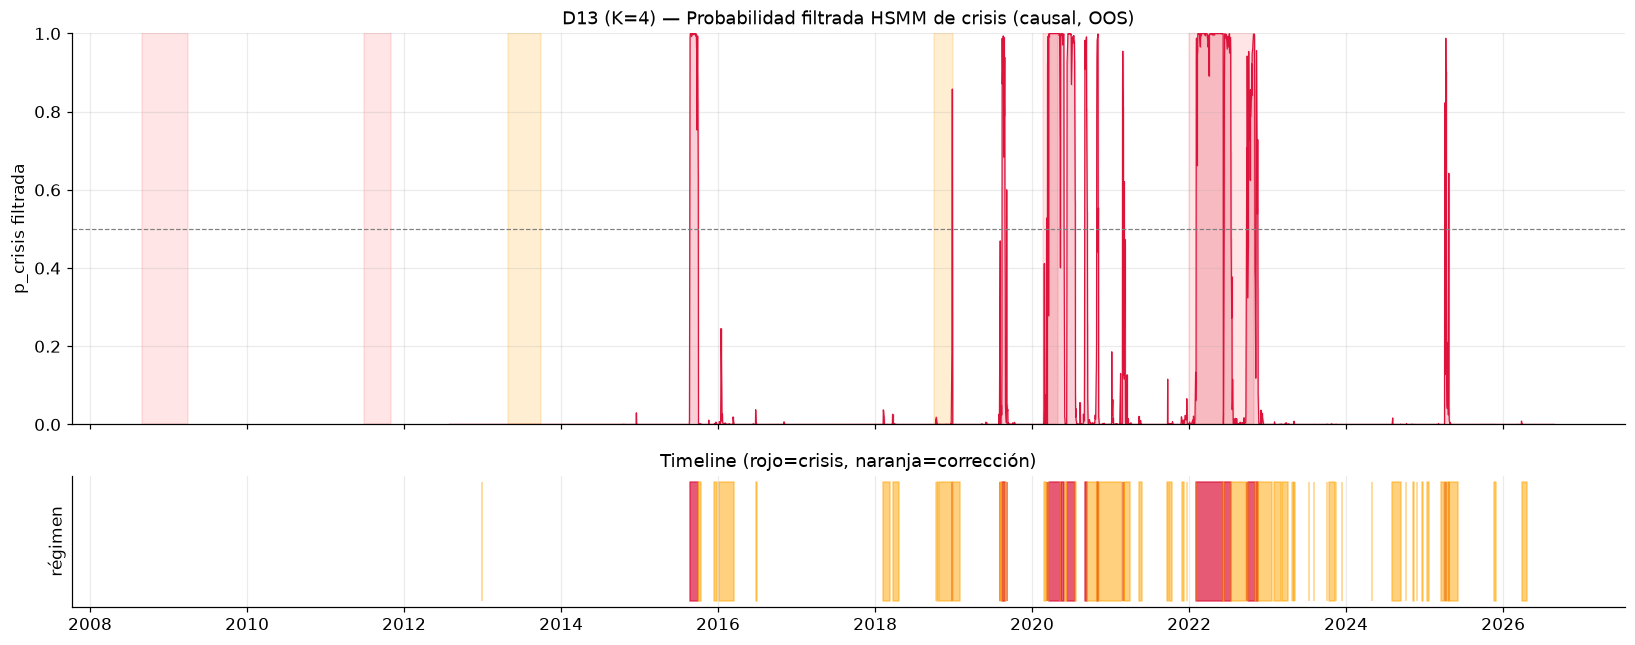

In [11]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 6), sharex=True,
                               gridspec_kw={'height_ratios': [3, 1]})
ax1.plot(panel.index, panel['p_crisis'], color='crimson', lw=0.8)
ax1.fill_between(panel.index, 0, panel['p_crisis'], color='crimson', alpha=0.20, step='mid')
ax1.axhline(0.5, color='grey', ls='--', lw=0.8)
ax1.set_ylabel('p_crisis filtrada'); ax1.set_ylim(0, 1)
ax1.set_title(f'D13 (K={K}) — Probabilidad filtrada HSMM de crisis (causal, OOS)')
for a, b in ev.CRISIS_WINDOWS.values():
    ax1.axvspan(pd.Timestamp(a), pd.Timestamp(b), color='red', alpha=0.10)
for a, b in ev.FALSE_POSITIVE_WINDOWS.values():
    ax1.axvspan(pd.Timestamp(a), pd.Timestamp(b), color='orange', alpha=0.18)
corr_state = K - 2
ax2.fill_between(panel.index, 0, 1, where=(states_oos == det.crisis_state).values,
                 color='crimson', alpha=0.7, step='mid')
ax2.fill_between(panel.index, 0, 1, where=(states_oos == corr_state).values,
                 color='orange', alpha=0.5, step='mid')
ax2.set_yticks([]); ax2.set_ylabel('régimen'); ax2.set_title('Timeline (rojo=crisis, naranja=corrección)')
fig.tight_layout(); fig.savefig(RESULTS / 'd13_hsmm_crisis_proba.png', dpi=110, bbox_inches='tight'); plt.show()


## <a id="s11"></a>11. Cadena embebida y duración esperada

En un HSMM la diagonal de la matriz embebida es cero: la permanencia no se representa con auto-transiciones, sino con la PMF de duración. El panel derecho sustituye la habitual lectura `1/(1-A_ss)` por `E[D_s]` calculada directamente.


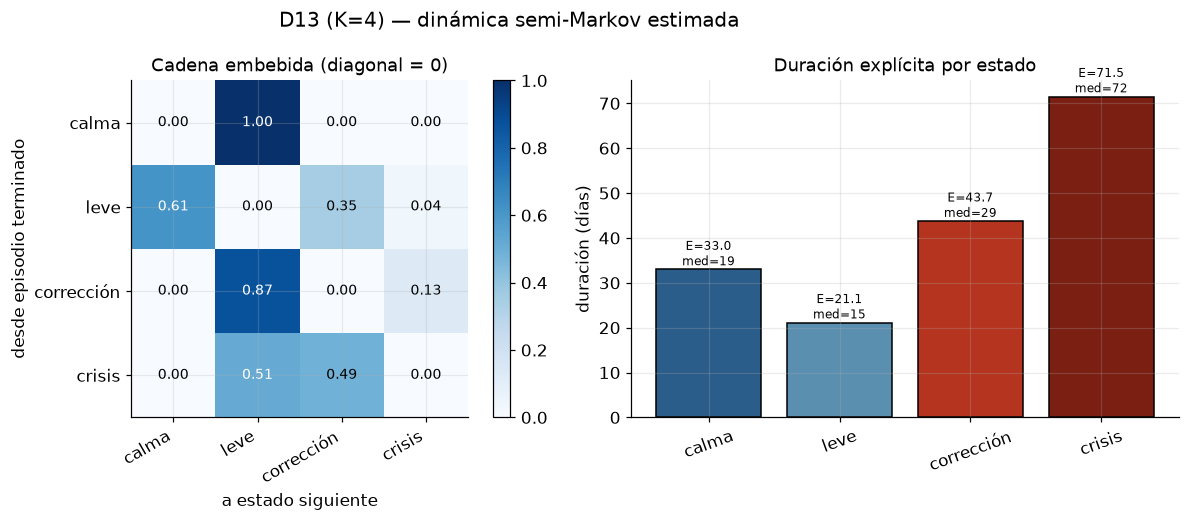

In [12]:
B = det.embedded_transition_canonical()
dur_mean = dur_par['mean_days'].values
fig, (axA, axB) = plt.subplots(1, 2, figsize=(12.5, 4.8), gridspec_kw={'width_ratios': [1.15, 1]})
im = axA.imshow(B, cmap='Blues', vmin=0, vmax=1)
axA.set_xticks(range(K), ST_LABELS, rotation=30, ha='right'); axA.set_yticks(range(K), ST_LABELS)
axA.set_xlabel('a estado siguiente'); axA.set_ylabel('desde episodio terminado')
for i in range(K):
    for j in range(K):
        axA.text(j, i, f'{B[i, j]:.2f}', ha='center', va='center',
                 color='white' if B[i, j] > 0.5 else 'black', fontsize=9)
axA.set_title('Cadena embebida (diagonal = 0)')
fig.colorbar(im, ax=axA, fraction=0.046, pad=0.04)
bars = axB.bar(range(K), dur_mean, color=[viz.regime_color(s, K) for s in range(K)], edgecolor='black')
for b, med in zip(bars, dur_par['median_days']):
    axB.text(b.get_x()+b.get_width()/2, b.get_height(), f'E={b.get_height():.1f}\nmed={med:.0f}',
             ha='center', va='bottom', fontsize=8)
axB.set_xticks(range(K), ST_LABELS, rotation=20); axB.set_ylabel('duración (días)')
axB.set_title('Duración explícita por estado')
fig.suptitle(f'D13 (K={K}) — dinámica semi-Markov estimada')
fig.tight_layout(); fig.savefig(RESULTS / 'd13_transition_duration.png', dpi=110, bbox_inches='tight'); plt.show()


## <a id="s12"></a>12. Verificación contra crisis, trampas y fragmentación

Además de sensibilidad y falsas alarmas, medimos directamente la fragmentación mediante el número de cambios y la duración media de las rachas OOS. Esta es la variable que D13 pretende mejorar frente a D8.


In [13]:
cov = ev.crisis_coverage(states_oos, det.crisis_state)
fa  = ev.false_alarm_in_windows(states_oos, det.crisis_state)
print('=== COBERTURA EN CRISIS (alto = bueno) ===')
for name, value in cov.items():
    print(f'  {name:16s}: ' + ('NaN (en train, no OOS)' if value != value else f'{value:6.1%}'))
print('\n=== ACTIVACIÓN CRISIS EN TRAMPAS (bajo = bueno) ===')
for name, value in fa.items():
    print(f'  {name:16s}: ' + ('NaN' if value != value else f'{value:6.1%}'))
print('\n=== ¿2013/2018 son corrección o superior? ===')
for name, (a, b) in ev.FALSE_POSITIVE_WINDOWS.items():
    seg = states_oos.loc[(states_oos.index >= pd.Timestamp(a)) & (states_oos.index <= pd.Timestamp(b))]
    if len(seg):
        print(f'  {name:16s}: corrección+crisis={(seg >= corr_state).mean():5.1%} '
              f'| solo crisis={(seg == det.crisis_state).mean():5.1%}')
n_changes = int((states_oos.values[1:] != states_oos.values[:-1]).sum())
print(f'\nCambios OOS={n_changes} | switching_rate={res.switching_rate:.4f} '
      f'| duración media={res.mean_regime_duration:.1f} días | estabilidad={res.label_stability:.3f}')


=== COBERTURA EN CRISIS (alto = bueno) ===
  GFC_2008        : NaN (en train, no OOS)
  EuroDebt_2011   : NaN (en train, no OOS)
  COVID_2020      :  68.0%
  Inflation_2022  :  62.3%

=== ACTIVACIÓN CRISIS EN TRAMPAS (bajo = bueno) ===
  TaperTantrum_2013:   0.0%
  Selloff_Q4_2018 :   1.7%

=== ¿2013/2018 son corrección o superior? ===
  TaperTantrum_2013: corrección+crisis= 0.0% | solo crisis= 0.0%
  Selloff_Q4_2018 : corrección+crisis=81.4% | solo crisis= 1.7%

Cambios OOS=170 | switching_rate=0.0495 | duración media=20.1 días | estabilidad=0.898


## <a id="s13"></a>13. Comparación controlada D13 vs D8 — ¿aporta la duración explícita?

Esta es la comparación central: mismas features, emisiones t, rango de K, train inicial y frecuencia de refit. La mejora esperada de D13 es **menor switching y mayor duración media** sin deteriorar de forma importante la cobertura, las falsas alarmas ni la estabilidad.

El BIC de D13 es aproximado por la estimación en dos etapas; se muestra con trama para recordar que su lectura es secundaria.


,switching_rate,mean_duration,false_alarm_rate,label_stability,BIC
D8 t-HMM,0.0475,20.9268,0.4113,0.8955,24129.1650
D13 t-HSMM,0.0495,20.0702,0.4137,0.8976,24295.6678


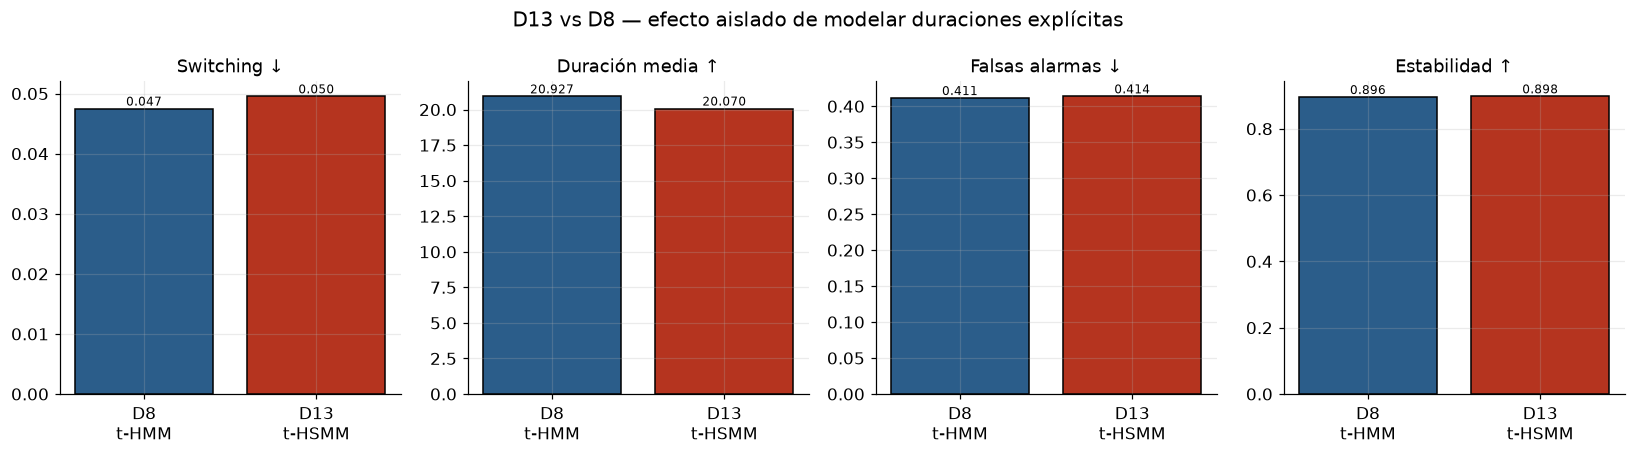

Δ switching (D13-D8) = +0.0020  [negativo favorece D13]
Δ duración media       = -0.9 días [positivo favorece D13]
Δ BIC aproximado       = +166.5 [negativo favorece D13; interpretar con cautela]


In [14]:
d8 = pd.read_csv(RESULTS / 'metrics_08_hmm_tstudent.csv').iloc[0]
cmp = pd.DataFrame({
    'D8 t-HMM': {
        'switching_rate': d8['switching_rate'],
        'mean_duration': d8['mean_regime_duration'],
        'false_alarm_rate': d8['false_alarm_rate'],
        'label_stability': d8['label_stability'],
        'BIC': d8['bic'],
    },
    'D13 t-HSMM': {
        'switching_rate': res.switching_rate,
        'mean_duration': res.mean_regime_duration,
        'false_alarm_rate': res.false_alarm_rate,
        'label_stability': res.label_stability,
        'BIC': res.bic,
    },
}).T
display(cmp.round(4))

metrics_plot = ['switching_rate', 'mean_duration', 'false_alarm_rate', 'label_stability']
titles = ['Switching ↓', 'Duración media ↑', 'Falsas alarmas ↓', 'Estabilidad ↑']
fig, axes = plt.subplots(1, 4, figsize=(15, 4.2))
colors = [viz.C_LONG, viz.C_CRISIS]
for ax, metric, title in zip(axes, metrics_plot, titles):
    vals = cmp[metric].values.astype(float)
    bars = ax.bar(['D8\nt-HMM', 'D13\nt-HSMM'], vals, color=colors, edgecolor='black')
    for b in bars:
        ax.text(b.get_x()+b.get_width()/2, b.get_height(), f'{b.get_height():.3f}',
                ha='center', va='bottom', fontsize=8)
    ax.set_title(title)
fig.suptitle('D13 vs D8 — efecto aislado de modelar duraciones explícitas')
fig.tight_layout(); fig.savefig(RESULTS / 'd13_vs_d8.png', dpi=110, bbox_inches='tight'); plt.show()

delta_switch = res.switching_rate - float(d8['switching_rate'])
delta_duration = res.mean_regime_duration - float(d8['mean_regime_duration'])
delta_bic = res.bic - float(d8['bic'])
print(f'Δ switching (D13-D8) = {delta_switch:+.4f}  [negativo favorece D13]')
print(f'Δ duración media       = {delta_duration:+.1f} días [positivo favorece D13]')
print(f'Δ BIC aproximado       = {delta_bic:+.1f} [negativo favorece D13; interpretar con cautela]')


## <a id="s14"></a>14. Conclusión y contraste con la hipótesis

La hipótesis se considera apoyada solo si D13 reduce la fragmentación de D8 **sin comprar esa mejora a costa de colapsar la sensibilidad**. La celda resume el veredicto con criterios declarados antes de mirar los resultados:

1. `switching_D13 < switching_D8`;
2. `duración_D13 > duración_D8`;
3. la cobertura media de crisis OOS no cae más de 10 puntos porcentuales;
4. la tasa global de falsas alarmas no empeora más de 10 puntos porcentuales.

La conclusión sigue siendo empírica y condicionada a `D_MAX` y a la fuerza del prior; una versión final debería añadir sensibilidad a ambos hiperparámetros y, si D13 aporta valor claro, contrastar un EM HSMM conjunto.


In [15]:
cov_d13 = np.nanmean(list(cov.values()))
cov_cols_d8 = [c for c in d8.index if str(c).startswith('cov_') and not str(c).endswith(('_lo', '_hi'))]
cov_d8 = float(pd.to_numeric(d8[cov_cols_d8], errors='coerce').mean())
fa_d8 = float(d8['false_alarm_rate'])

checks = {
    'menos switching': res.switching_rate < float(d8['switching_rate']),
    'mayor duración media': res.mean_regime_duration > float(d8['mean_regime_duration']),
    'cobertura no cae >10 pp': cov_d13 >= cov_d8 - 0.10,
    'falsas alarmas no suben >10 pp': res.false_alarm_rate <= fa_d8 + 0.10,
}
print('Resumen D13 hsmm_tstudent')
print(f'  K*={K} | D_MAX={D_MAX} | prior duración={DURATION_PRIOR:g}')
print(f'  BIC aproximado D13={res.bic:.0f} vs D8={float(d8["bic"]):.0f}')
print(f'  monotonía vol: in-sample={mono_vol_is} | walk-forward={mono_vol_wf}')
print(f'  duración explícita E[D] por estado:', np.round(dur_par['mean_days'].values, 1))
print(f'  cobertura media OOS: D13={cov_d13:.1%} vs D8={cov_d8:.1%}')
print(f'  switching: D13={res.switching_rate:.4f} vs D8={float(d8["switching_rate"]):.4f}')
print('\nCriterios previos:')
for label, ok in checks.items():
    print(f'  [{"OK" if ok else "FALLA"}] {label}')
print('\nVEREDICTO:', 'hipótesis APOYADA en los cuatro criterios' if all(checks.values())
      else 'hipótesis NO apoyada completamente; revisar métricas y sensibilidad antes de concluir')


Resumen D13 hsmm_tstudent
  K*=4 | D_MAX=126 | prior duración=12
  BIC aproximado D13=24296 vs D8=24129
  monotonía vol: in-sample=True | walk-forward=True
  duración explícita E[D] por estado: [33.  21.1 43.7 71.5]
  cobertura media OOS: D13=65.2% vs D8=65.1%
  switching: D13=0.0495 vs D8=0.0475

Criterios previos:
  [FALLA] menos switching
  [FALLA] mayor duración media
  [OK] cobertura no cae >10 pp
  [OK] falsas alarmas no suben >10 pp

VEREDICTO: hipótesis NO apoyada completamente; revisar métricas y sensibilidad antes de concluir


Los resultados no respaldan la hipótesis de que la duración explícita del HSMM mejore la dinámica temporal del HMM t-Student. D13 produce una segmentación prácticamente idéntica a D8 y no mejora las dos variables que motivaban su implementación: la tasa de cambio de régimen aumenta ligeramente (`0.0475 → 0.0495`) y la duración media disminuye (`20.93 → 20.07` días).

El resto de las diferencias tampoco resulta material. La tasa de falsas alarmas permanece prácticamente constante (`0.411 → 0.414`), la estabilidad apenas aumenta (`0.896 → 0.898`) y la cobertura media de las crisis OOS es esencialmente la misma. D13 mejora la cobertura de COVID en 2 puntos porcentuales (`0.66 → 0.68`), pero pierde aproximadamente la misma cantidad durante el episodio inflacionario de 2022 (`0.643 → 0.623`). Los indicadores de anticipación son idénticos en ambos modelos.

| Métrica | D8 t-HMM | D13 t-HSMM | Cambio |
|---|---:|---:|---:|
| *Switching rate* | 0.0475 | 0.0495 | Empeora |
| Duración media | 20.93 días | 20.07 días | Empeora |
| Falsas alarmas | 0.411 | 0.414 | Sin cambio material |
| Estabilidad | 0.896 | 0.898 | Mejora insignificante |
| Cobertura COVID-2020 | 0.660 | 0.680 | +2 pp |
| Cobertura Inflación-2022 | 0.643 | 0.623 | −1.9 pp |
| BIC | 24 129 | 24 296 | D13 peor |
| *Lead/lag* COVID / Inflación | −149 / −171 | −149 / −171 | Idéntico |

El BIC de D13 también es superior —y, por tanto, peor—, aunque esta comparación debe interpretarse con cautela porque el HSMM se estima en dos etapas y no mediante un EM conjunto. En cualquier caso, no existe evidencia empírica de una ganancia que justifique su complejidad adicional.

Por tanto, **D13 no se selecciona como detector principal**. Se mantiene como una extensión exploratoria y como resultado negativo informativo: bajo esta especificación, sustituir la permanencia geométrica de D8 por una distribución explícita de duraciones no aporta una mejora incremental. Por parsimonia, rendimiento equivalente y menor complejidad, **D8 `hmm_tstudent_4s` continúa siendo el representante seleccionado de la familia F3**.

Este resultado tampoco justifica, en esta fase, desarrollar un HSMM con estimación conjunta mediante EM ni ampliar la búsqueda de hiperparámetros. Tales extensiones solo serían razonables si el modelado explícito de las duraciones constituyera por sí mismo una pregunta central de investigación.